In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
from tqdm import tqdm
import json
from typing import Optional, Tuple
import os

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


### 1) Loading numpy arrays

In [19]:
TENSOR_DIR = 'tensors_gpt/'  # Update to your path

# Load metadata
with open('tensors_rep/metadata.json', 'r') as f:
    metadata = json.load(f)

# Load tensors
X_train = np.load(TENSOR_DIR + 'X_train.npy')
X_val = np.load(TENSOR_DIR + 'X_val.npy')
X_test = np.load(TENSOR_DIR + 'X_test.npy')
y_train = np.load(TENSOR_DIR + 'y_train.npy')
y_val = np.load(TENSOR_DIR + 'y_val.npy')
y_test = np.load(TENSOR_DIR + 'y_test.npy')
mask_train = np.load(TENSOR_DIR + 'mask_train.npy')
mask_val = np.load(TENSOR_DIR + 'mask_val.npy')
mask_test = np.load(TENSOR_DIR + 'mask_test.npy')

# Get feature lists
original_features = metadata['original_features']   # 15 features
gap_features = metadata['gap_features']             # 15 features
all_features = metadata['all_features']             # 30 features
T = metadata['T']

print(f"X_train: {X_train.shape}  (N, T, F)")
print(f"mask_train: {mask_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Train mortality: {y_train.mean()*100:.1f}%")
print(f"Features: {len(all_features)} total ({len(original_features)} original + {len(gap_features)} time gaps)")

X_train: (45756, 48, 30)  (N, T, F)
mask_train: (45756, 48)
y_train: (45756,)
Train mortality: 11.0%
Features: 30 total (15 original + 15 time gaps)


In [20]:
class ICUDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask = torch.tensor(mask.astype(bool), dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

In [4]:
drop_features = [
    'respiratory_rate',
    'sbp', 
    'wbc',
    'time_since_last_age',
    'time_since_last_gender'
]

drop_indices = [all_features.index(f) for f in drop_features]
keep_indices = [i for i in range(len(all_features)) if i not in drop_indices]
feature_names_clean = [all_features[i] for i in keep_indices]

print(f"Original features: {len(all_features)} → Kept: {len(feature_names_clean)}")
print("Kept features:", feature_names_clean)

# Apply to raw arrays
X_train_clean = X_train[:, :, keep_indices]
X_val_clean   = X_val[:, :, keep_indices]
X_test_clean  = X_test[:, :, keep_indices]

Original features: 30 → Kept: 25
Kept features: ['creatinine', 'glucose', 'sodium', 'potassium', 'hematocrit', 'heart_rate', 'dbp', 'mbp', 'temperature', 'spo2', 'age', 'gender', 'time_since_last_creatinine', 'time_since_last_glucose', 'time_since_last_sodium', 'time_since_last_potassium', 'time_since_last_hematocrit', 'time_since_last_wbc', 'time_since_last_heart_rate', 'time_since_last_sbp', 'time_since_last_dbp', 'time_since_last_mbp', 'time_since_last_respiratory_rate', 'time_since_last_temperature', 'time_since_last_spo2']


In [4]:
def fix_tensors_safe(X_train, X_val, X_test, feature_names):
    """
    Clip time_since_last features to [0,48] and all other features
    to train-set 1st–99th percentiles.
    """
    X_train_fixed = X_train.copy() if not torch.is_tensor(X_train) else X_train.clone().numpy()
    X_val_fixed   = X_val.copy()   if not torch.is_tensor(X_val)   else X_val.clone().numpy()
    X_test_fixed  = X_test.copy()  if not torch.is_tensor(X_test)  else X_test.clone().numpy()
    
    n_features = X_train_fixed.shape[2]
    
    # Identify time_since_last features
    time_feature_indices = [i for i, name in enumerate(feature_names) 
                            if 'time_since_last' in name]
    
    # Clip time_since_last to [0,48]
    for idx in time_feature_indices:
        X_train_fixed[:, :, idx] = np.clip(X_train_fixed[:, :, idx], 0, 48)
        X_val_fixed[:, :, idx]   = np.clip(X_val_fixed[:, :, idx], 0, 48)
        X_test_fixed[:, :, idx]  = np.clip(X_test_fixed[:, :, idx], 0, 48)
    
    # Clip other features using train percentiles
    for feat_idx in range(n_features):
        if feat_idx in time_feature_indices:
            continue
        
        train_vals = X_train_fixed[:, :, feat_idx].flatten()
        lower = np.percentile(train_vals, 1)
        upper = np.percentile(train_vals, 99)
        
        X_train_fixed[:, :, feat_idx] = np.clip(X_train_fixed[:, :, feat_idx], lower, upper)
        X_val_fixed[:, :, feat_idx]   = np.clip(X_val_fixed[:, :, feat_idx], lower, upper)
        X_test_fixed[:, :, feat_idx]  = np.clip(X_test_fixed[:, :, feat_idx], lower, upper)
        
        print(f"  {feature_names[feat_idx]}: [{lower:.3f}, {upper:.3f}]")
    
    # Convert back to torch tensors
    X_train_fixed = torch.tensor(X_train_fixed, dtype=torch.float32)
    X_val_fixed   = torch.tensor(X_val_fixed, dtype=torch.float32)
    X_test_fixed  = torch.tensor(X_test_fixed, dtype=torch.float32)
    
    return X_train_fixed, X_val_fixed, X_test_fixed

### Option 1

In [6]:
X_train_fixed, X_val_fixed, X_test_fixed = fix_tensors_safe(
    X_train_clean, X_val_clean, X_test_clean, feature_names_clean
)

# Quick verification
for name, X in [('train', X_train_fixed), ('val', X_val_fixed), ('test', X_test_fixed)]:
    print(f"{name} — min: {X.min():.3f}, max: {X.max():.3f}, "
          f"extreme(>100): {(X.abs() > 100).sum().item()}")

  creatinine: [-0.698, 4.536]
  glucose: [-0.148, 0.187]
  sodium: [-1.268, 3.794]
  potassium: [-0.359, 0.458]
  hematocrit: [-2.061, 2.561]
  heart_rate: [-2.070, 3.206]
  dbp: [-0.286, 0.355]
  mbp: [-2.682, 2.659]
  temperature: [-2.562, 0.343]
  spo2: [-1.082, 2.478]
  age: [-0.455, 4.021]
  gender: [-1.144, 0.885]
train — min: -2.682, max: 6.169, extreme(>100): 0
val — min: -2.682, max: 6.169, extreme(>100): 0
test — min: -2.682, max: 6.169, extreme(>100): 0


### Option 2

In [5]:
X_train_fixed, X_val_fixed, X_test_fixed = fix_tensors_safe(
    X_train, X_val, X_test, all_features
)

# Quick verification
for name, X in [('train', X_train_fixed), ('val', X_val_fixed), ('test', X_test_fixed)]:
    print(f"{name} — min: {X.min():.3f}, max: {X.max():.3f}, "
          f"extreme(>100): {(X.abs() > 100).sum().item()}")

  creatinine: [-0.698, 4.536]
  glucose: [-0.148, 0.187]
  sodium: [-1.268, 3.794]
  potassium: [-0.359, 0.458]
  hematocrit: [-2.061, 2.561]
  wbc: [-0.040, 0.049]
  heart_rate: [-2.070, 3.206]
  sbp: [-0.015, 0.019]
  dbp: [-0.286, 0.355]
  mbp: [-2.682, 2.659]
  respiratory_rate: [-0.003, 0.000]
  temperature: [-2.562, 0.343]
  spo2: [-1.082, 2.478]
  age: [-0.455, 4.021]
  gender: [-1.144, 0.885]
train — min: -2.682, max: 6.169, extreme(>100): 0
val — min: -2.682, max: 6.169, extreme(>100): 0
test — min: -2.682, max: 6.169, extreme(>100): 0


### Option 1

In [6]:
# Convert to numpy for dataset constructor (ICUDataset expects numpy)
X_train_np = X_train_fixed.numpy()
X_val_np   = X_val_fixed.numpy()
X_test_np  = X_test_fixed.numpy()

# Create datasets
train_ds = ICUDataset(X_train_np, mask_train, y_train)
val_ds   = ICUDataset(X_val_np,   mask_val,   y_val)
test_ds  = ICUDataset(X_test_np,  mask_test,  y_test)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print(f"\nReady: input_dim = {X_train_fixed.shape[2]}, features = {feature_names_clean}")

NameError: name 'feature_names_clean' is not defined

### Option 2

In [22]:
# Create datasets
train_ds = ICUDataset(X_train, mask_train, y_train)
val_ds   = ICUDataset(X_val,   mask_val,   y_val)
test_ds  = ICUDataset(X_test,  mask_test,  y_test)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print(f"\nReady: input_dim = {X_train.shape[2]}, features = {all_features}")


Ready: input_dim = 30, features = ['creatinine', 'glucose', 'sodium', 'potassium', 'hematocrit', 'wbc', 'heart_rate', 'sbp', 'dbp', 'mbp', 'respiratory_rate', 'temperature', 'spo2', 'age', 'gender', 'time_since_last_creatinine', 'time_since_last_glucose', 'time_since_last_sodium', 'time_since_last_potassium', 'time_since_last_hematocrit', 'time_since_last_wbc', 'time_since_last_heart_rate', 'time_since_last_sbp', 'time_since_last_dbp', 'time_since_last_mbp', 'time_since_last_respiratory_rate', 'time_since_last_temperature', 'time_since_last_spo2', 'time_since_last_age', 'time_since_last_gender']


### Option 3

In [7]:
# Convert to numpy for dataset constructor (ICUDataset expects numpy)
X_train_np = X_train_fixed.numpy()
X_val_np   = X_val_fixed.numpy()
X_test_np  = X_test_fixed.numpy()

# Create datasets
train_ds = ICUDataset(X_train_np, mask_train, y_train)
val_ds   = ICUDataset(X_val_np,   mask_val,   y_val)
test_ds  = ICUDataset(X_test_np,  mask_test,  y_test)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print(f"\nReady: input_dim = {X_train_fixed.shape[2]}, features = {all_features}")


Ready: input_dim = 30, features = ['creatinine', 'glucose', 'sodium', 'potassium', 'hematocrit', 'wbc', 'heart_rate', 'sbp', 'dbp', 'mbp', 'respiratory_rate', 'temperature', 'spo2', 'age', 'gender', 'time_since_last_creatinine', 'time_since_last_glucose', 'time_since_last_sodium', 'time_since_last_potassium', 'time_since_last_hematocrit', 'time_since_last_wbc', 'time_since_last_heart_rate', 'time_since_last_sbp', 'time_since_last_dbp', 'time_since_last_mbp', 'time_since_last_respiratory_rate', 'time_since_last_temperature', 'time_since_last_spo2', 'time_since_last_age', 'time_since_last_gender']


### Option 1

In [ ]:
from Scripts.model_gpt import ChainOfInfluence

# Get input dimension from your fixed tensors
input_dim = X_train_fixed.shape[2]   # number of features after cleaning

model = ChainOfInfluence(
    n_features=input_dim,
    d_model=64,
    lstm_hidden=32,
    n_heads=4,
    n_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    max_len=48,
    use_mask_as_padding=False
).to(DEVICE)

print(f"Model built with input_dim={input_dim}")

Model built with input_dim=30


### Option 2

In [ ]:
from Scripts.model_gpt import ChainOfInfluence

# Get input dimension from your fixed tensors
input_dim = X_train.shape[2]   # number of features after cleaning

model = ChainOfInfluence(
    n_features=input_dim,
    d_model=64,
    lstm_hidden=32,
    n_heads=4,
    n_layers=2,
    dim_feedforward=256,
    dropout=0.2,
    max_len=48,
    use_mask_as_padding=False
).to(DEVICE)

print(f"Model built with input_dim={input_dim}")

Model built with input_dim=30


In [24]:
# Compute pos_weight from training set (inverse class frequency)
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()
pos_weight = torch.tensor([num_neg / num_pos * 0.5], device=DEVICE) if num_pos > 0 else None
print(f"pos_weight = {pos_weight}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

pos_weight = tensor([4.0556], device='cuda:0', dtype=torch.float64)


In [25]:
from Scripts.train_coi import train_coi

model = train_coi(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    epochs=50,
    lr=1e-4,
    patience=10,
    pos_weight=pos_weight  # Use corrected pos_weight
)

Epoch  10 | loss=0.5949 | val_loss=0.5965 | val_auroc=0.8470
Epoch  20 | loss=0.5571 | val_loss=0.5762 | val_auroc=0.8612
Epoch  30 | loss=0.5426 | val_loss=0.5529 | val_auroc=0.8697
Epoch  40 | loss=0.5323 | val_loss=0.5538 | val_auroc=0.8701
Early stop at epoch 40 | best val_loss=0.5529


In [26]:
torch.save(model.state_dict(), 'Weights/best_model_gpt_direct.pt')

In [27]:
from Scripts.evaluate import evaluate_test, find_optimal_threshold, print_detailed_metrics, get_predictions

# 1. First find optimal threshold on validation set
best_threshold = find_optimal_threshold(model, val_loader, DEVICE)

# 2. Evaluate on test set with optimal threshold
test_metrics, test_probs, test_labels, test_preds = evaluate_test(
    model, test_loader, DEVICE, threshold=best_threshold
)

# 3. Print detailed metrics
print_detailed_metrics(test_metrics, test_labels, test_preds, test_probs)

# 4. (Optional) Get predictions for further analysis
probs, labels = get_predictions(model, test_loader, DEVICE)

test_metrics, test_probs, test_labels, test_preds = evaluate_test(
    model, test_loader, DEVICE, threshold=0.5
)

# 3. Print detailed metrics
print_detailed_metrics(test_metrics, test_labels, test_preds, test_probs)

# 4. (Optional) Get predictions for further analysis
probs, labels = get_predictions(model, test_loader, DEVICE)

Optimal threshold: 0.600 (F1: 0.5354)

TEST SET RESULTS

📊 Core Metrics:
   AUROC:      0.8713
   Accuracy:   0.8934
   F1 Score:   0.5329
   Precision:  0.5134
   Recall:     0.5539
   Threshold:  0.600

📈 Confusion Matrix:
              Predicted
              Neg   Pos
   Actual Neg   8164    565
          Pos    480    596

📉 Additional Metrics:
   Specificity: 0.9353
   NPV:         0.9445

📋 Classification Report:
              precision    recall  f1-score   support

    Survived       0.94      0.94      0.94      8729
   Mortality       0.51      0.55      0.53      1076

    accuracy                           0.89      9805
   macro avg       0.73      0.74      0.74      9805
weighted avg       0.90      0.89      0.90      9805


📊 Test Set Distribution:
   Mortality:  1076 (11.0%)
   Survived:   8729 (89.0%)

TEST SET RESULTS

📊 Core Metrics:
   AUROC:      0.8713
   Accuracy:   0.8706
   F1 Score:   0.5213
   Precision:  0.4387
   Recall:     0.6422
   Threshold:  0.500



Randomly selected dead patient #589 of 1076 total dead patients


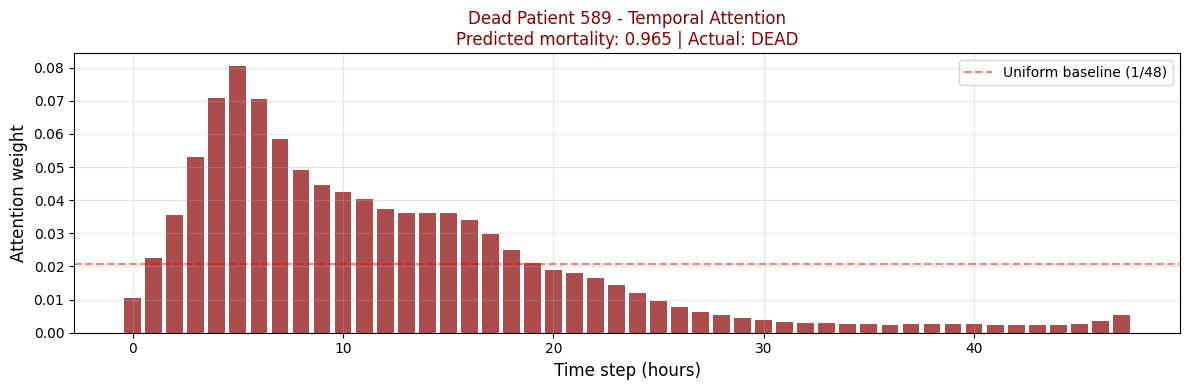


Dead Patient 589:
  True label: DEAD
  Predicted probability: 0.9649
  Peak attention at time step 5: 0.0804
  Attention entropy: 3.3771
  Max / uniform ratio: 3.86x


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_dead_patient_attention(model, test_loader, device, patient_idx=None):
    """
    Visualize temporal attention for a random dead patient (y_true = 1).
    
    Args:
        model: Trained ChainOfInfluence model
        test_loader: DataLoader for test set
        device: torch device
        patient_idx: Optional specific patient index (None = random dead patient)
    """
    model.eval()
    
    # Collect all dead patients first
    dead_patients = []
    dead_labels = []
    dead_probs = []
    
    with torch.no_grad():
        for X_b, mask_b, y_b in test_loader:
            X_b = X_b.to(device)
            mask_b = mask_b.to(device)
            
            logits, info = model(X_b, mask=mask_b, return_attentions=True)
            probs = torch.sigmoid(logits).cpu().numpy()
            y_np = y_b.cpu().numpy()
            alpha = info['alpha'].squeeze(-1).cpu().numpy()  # (B, T)
            
            # Find dead patients in this batch (y_true == 1)
            dead_indices = np.where(y_np == 1)[0]
            for idx in dead_indices:
                dead_patients.append(alpha[idx])
                dead_labels.append(y_np[idx])
                dead_probs.append(probs[idx])
    
    if len(dead_patients) == 0:
        print("No dead patients found in test set!")
        return None, None, None
    
    # Select patient
    if patient_idx is None or patient_idx >= len(dead_patients):
        patient_idx = np.random.randint(0, len(dead_patients))
        print(f"Randomly selected dead patient #{patient_idx} of {len(dead_patients)} total dead patients")
    
    alpha = dead_patients[patient_idx]
    y_true = dead_labels[patient_idx]
    prob = dead_probs[patient_idx]
    
    # Normalize attention to sum to 1
    alpha_norm = alpha / alpha.sum()
    
    # Plot
    plt.figure(figsize=(12, 4))
    plt.bar(range(len(alpha_norm)), alpha_norm, width=0.8, color='darkred', alpha=0.7)
    plt.xlabel('Time step (hours)', fontsize=12)
    plt.ylabel('Attention weight', fontsize=12)
    plt.title(f'Dead Patient {patient_idx} - Temporal Attention\n'
              f'Predicted mortality: {prob:.3f} | Actual: DEAD',
              fontsize=12, color='darkred')
    plt.axhline(y=1/len(alpha_norm), color='red', linestyle='--', alpha=0.5,
                label=f'Uniform baseline (1/{len(alpha_norm)})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print stats
    peak_t = np.argmax(alpha_norm)
    print(f"\nDead Patient {patient_idx}:")
    print(f"  True label: DEAD")
    print(f"  Predicted probability: {prob:.4f}")
    print(f"  Peak attention at time step {peak_t}: {alpha_norm[peak_t]:.4f}")
    print(f"  Attention entropy: {-np.sum(alpha_norm * np.log(alpha_norm+1e-10)):.4f}")
    print(f"  Max / uniform ratio: {alpha_norm[peak_t] / (1/len(alpha_norm)):.2f}x")
    
    return alpha_norm, prob, y_true

# Run for a random dead patient
attention_weights, pred_prob, true_label = visualize_dead_patient_attention(model, test_loader, DEVICE)

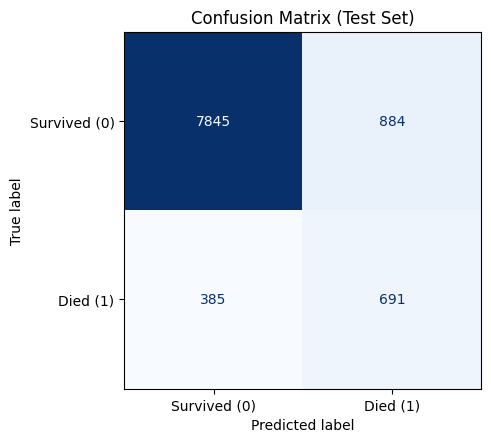

In [28]:
# ...existing code...
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# If needed, uncomment to derive preds from probabilities:
# threshold = 0.5
# test_preds = (np.array(test_probs) >= threshold).astype(int)

cm = confusion_matrix(test_labels, test_preds, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Survived (0)", "Died (1)"]
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()
# ...existing code...